## 9. Evaluate model performance

This block compares the two trained models, the baseline heterogeneous GNN and the HGT model, on the held-out validation and test data.

This block evaluates the models from three different angles:

- **binary classification performance**, which checks how well the models separate positive and negative drug–disease pairs
- **ranking performance**, which checks how well the models prioritize true candidate drugs near the top of the list for each disease
- **safety diagnostics**, which check whether the recommendations leak known training edges or include contraindicated drugs

### Section 1: Set up evaluation inputs

The block performs guard checks to make sure the required objects from earlier blocks already exist, including:

- the trained baseline model
- the trained HGT model
- the training graph
- the target supervision edge type
- the positive edge sets
- the processed edge and node tables

The code then moves the graph and supervision tensors to the active device so evaluation can run on either GPU or CPU.

Two additional lookup structures are created before computing metrics:

- **`CONTRA_BY_DISEASE`**, which maps each disease to the set of drugs that are known contraindications for that disease
- **`TRAIN_POS_BY_DISEASE`**, which maps each disease to the set of indication edges already seen during training

These structures are later used for the safety analysis. The first helps identify potentially unsafe recommendations, while the second helps measure whether a model is simply reproducing training links instead of suggesting novel candidates.

### Section 2: Compute binary classification metrics

The first evaluation view treats link prediction as a binary classification problem. For both the validation and test splits, the models are asked to score:

- known positive drug–disease pairs
- sampled negative drug–disease pairs

The helper function `compute_binary_metrics(...)` handles this evaluation. It runs the model on the positive and negative pairs, converts logits into probabilities, and then computes a full set of classification metrics.

The reported metrics include:

- **AUROC**
- **AUPRC**, which is especially useful for link prediction because it emphasizes precision–recall behavior
- **accuracy**
- **balanced accuracy**
- **precision**
- **recall**
- **F1 score**
- **MCC**
- **log loss**
- **Brier score**
- **ECE**, which gives a rough measure of probability calibration

The function also computes the mean predicted score for positives and negatives, along with the gap between them. This helps show whether the model produces clear separation between the two groups.

For threshold-based metrics like accuracy and F1, the block chooses the threshold that maximizes F1 on the evaluated split.

### Section 3: Compute ranking metrics

The second evaluation view treats the task as a ranking problem rather than simple binary classification.

In real drug repurposing use, the goal is not just to classify isolated pairs as positive or negative. Instead, for a given disease, the model should rank many candidate drugs and place the most promising ones near the top. This section measures exactly that.

The helper function `compute_ranking_metrics(...)` does the following for each disease in the test set:

1. score **all drugs** for that disease
2. mask out drugs that were already seen as positive in training
3. sort all candidate drugs by predicted score
4. check where the true test-positive drugs appear in that ranking

From this ranking, the block computes several information retrieval metrics, including:

- **Hits@K**, which checks whether at least one true drug appears in the top K
- **Recall@K**, which measures how many true drugs are recovered within the top K
- **Precision@K**, which measures how many of the top-K predictions are actually correct
- **NDCG@K**, which rewards placing true drugs higher in the ranked list
- **MRR**, which emphasizes how early the first correct drug appears
- **mean rank** and **median rank**

### Section 4: Compute safety diagnostics

The third evaluation view checks whether the model’s top-ranked predictions are safe and genuinely novel.

The helper function `compute_safety_metrics(...)` looks at the **top 10** recommendations for each disease in the test set and calculates two rates:

- **`leakage_rate@10`**, which measures how many of the top 10 drugs were already seen as positive for that disease during training
- **`contra_rate@10`**, which measures how many of the top 10 drugs are known contraindications for that disease

### Section 5: Build a side-by-side comparison table

After computing the three groups of metrics, the block combines them into one summary dataframe called `comparison_df`.

This table groups results into:
- **Binary Classification**
- **Ranking**
- **Safety**

and places the **Baseline** and **HGT** results side by side.

### Section 6: Generate evaluation plots

The last major part of the block creates several figures to visualize the comparison between the two models.

#### ROC and Precision–Recall curves

The first figure plots:
- the **ROC curves**
- the **Precision–Recall curves**

for the test split. These plots show the trade-off between true positives and false positives across thresholds, and they help compare the overall scoring quality of the baseline and HGT models visually.

#### Score distribution histograms

The next figure plots histograms of predicted probabilities for:
- positive pairs
- negative pairs

for each model.

These plots make it easier to see how well the score distributions separate. A stronger model should generally show less overlap between the positive and negative histograms.

#### Ranking bar charts

Another figure compares the two models on ranking metrics across multiple values of K. The plots include:
- **Hits@K**
- **NDCG@K**

These visualizations make it easier to see whether the HGT model consistently outperforms the baseline across different cutoffs rather than only at a single K value.

#### Training curve overlay

If both training history dataframes are available, the block also overlays:
- training loss
- validation AUROC
- validation AUPRC

for the baseline and HGT models.


Contraindication entries  : 30675
Train positive entries    : 6571

Computing binary metrics ...
  Baseline   [val]  AUROC=0.9262  AUPRC=0.9347  F1=0.8406
  Baseline   [test]  AUROC=0.9173  AUPRC=0.9274  F1=0.8339
  HGT        [val]  AUROC=0.9533  AUPRC=0.9577  F1=0.8824
  HGT        [test]  AUROC=0.9453  AUPRC=0.9506  F1=0.8754

Computing ranking metrics ...
  Baseline    MRR=0.0586  Hits@10=0.0785  NDCG@10=0.0562
  HGT         MRR=0.0407  Hits@10=0.1169  NDCG@10=0.0482

Computing safety metrics ...
  Baseline    leakage@10=0.0318  contra@10=0.0228
  HGT         leakage@10=0.0454  contra@10=0.0128

  MODEL COMPARISON — TEST SPLIT


Baseline       HGT
Group                 Metric                               
Binary Classification auroc                0.9173    0.9453
                      auprc                0.9274    0.9506
                      f1                   0.8339    0.8754
                      mcc                  0.6708    0.7516
                      accuracy             0.8353    0.8758
                      balanced_accuracy    0.8353    0.8758
                      precision            0.8412    0.8779
                      recall               0.8268    0.8730
                      log_loss             0.6344    0.6049
                      brier_score          0.2207    0.2061
                      ece                  0.2879    0.3147
                      pos_mean_score       0.5318    0.5512
                      neg_mean_score       0.4692    0.4562
                      score_gap            0.0626    0.0950
                      threshold            0.4889    0.5062
Ranking               mrr                  0.0586    0.0407
                      mean_rank          810.8956  773.9478
                      median_rank        436.0000  345.0000
                      hits@1               0.0338    0.0046
                      hits@3               0.0631    0.0262
                      hits@5               0.0677    0.0538
                      hits@10              0.0785    0.1169
                      hits@20              0.1185    0.2092
                      hits@50              0.2123    0.3200
                      recall@10            0.0362    0.0669
                      recall@50            0.1211    0.2240
                      precision@10         0.0083    0.0128
                      ndcg@10              0.0562    0.0482
                      ndcg@50              0.0817    0.0943
Safety                leakage_rate@10      0.0318    0.0454
                      contra_rate@10       0.0228    0.0128

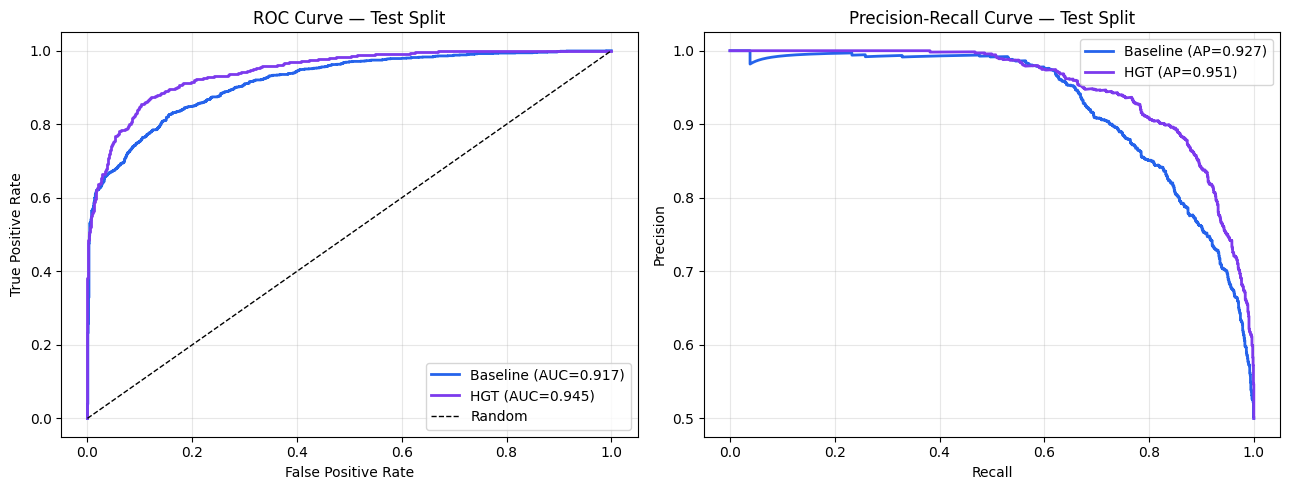

[Plot 1+2] ROC and PR curves saved.


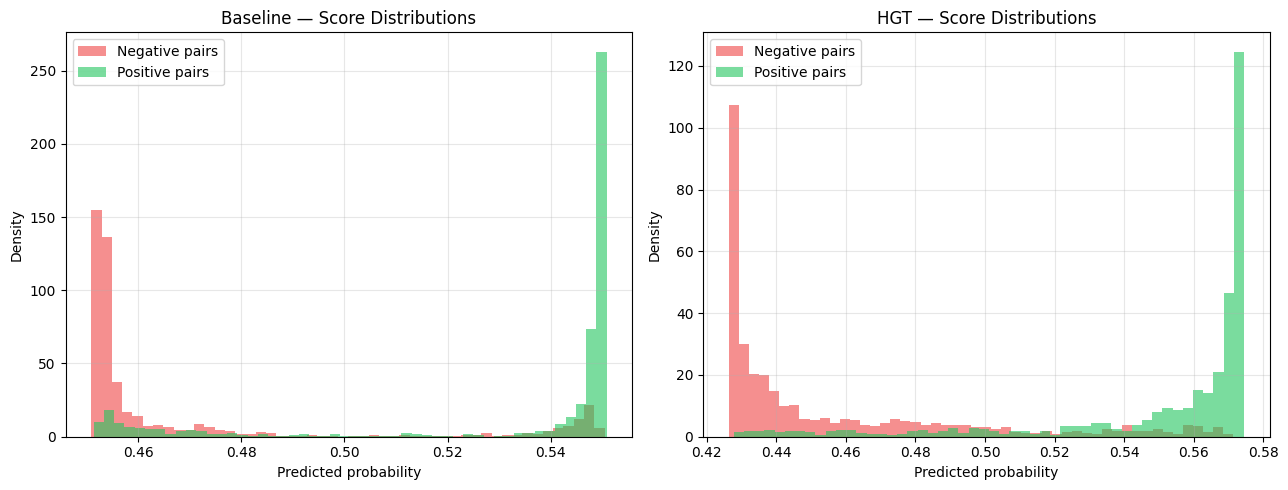

[Plot 3] Score distribution histograms saved.


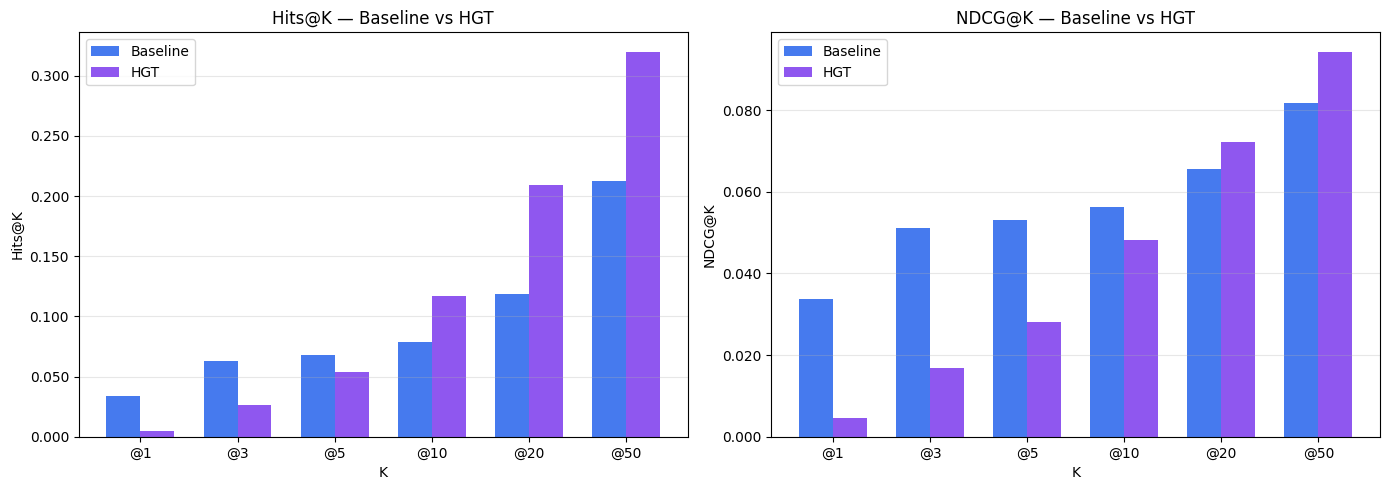

[Plot 4] Hits@K and NDCG@K bar charts saved.


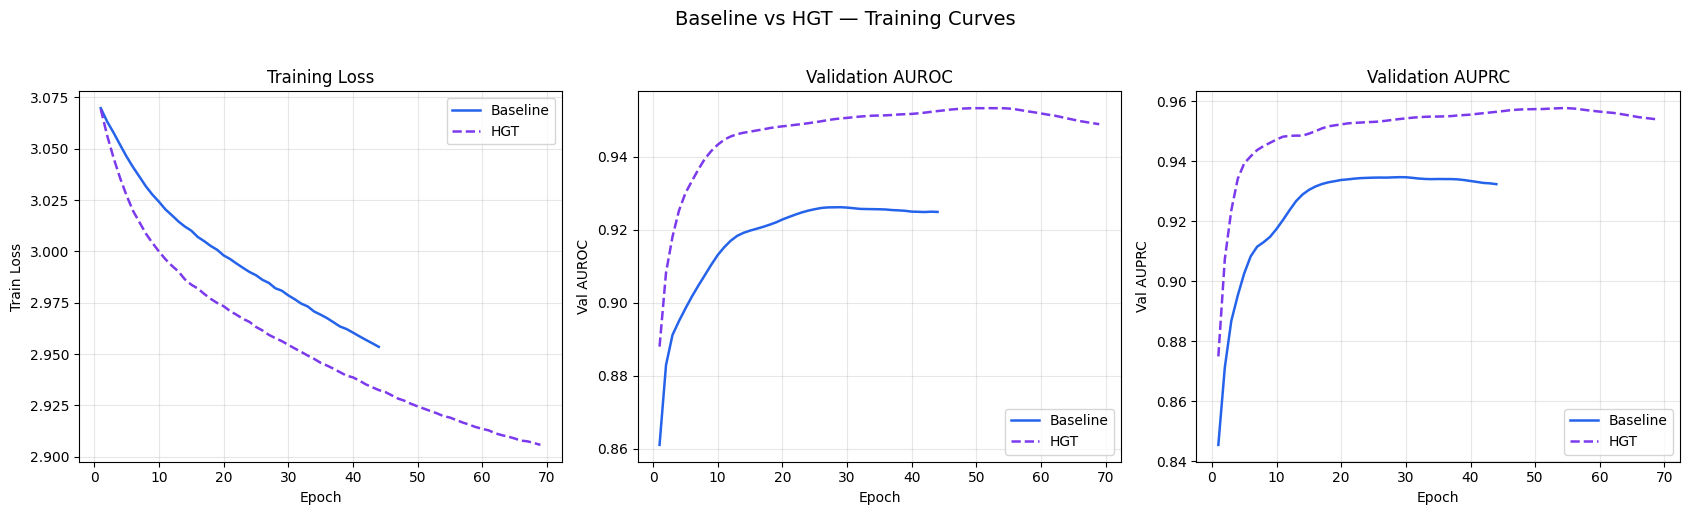

[Plot 5] Training curves overlay saved.

  BLOCK 09 COMPLETE
  Objects now available:
    binary_metrics    {model_name: {split: metrics_dict}}
    ranking_metrics   {model_name: metrics_dict}
    safety_metrics    {model_name: metrics_dict}
    comparison_df     full side-by-side DataFrame

  Figures saved to /mnt/data/:
    eval_roc_pr_curves.png
    eval_score_distributions.png
    eval_ranking_bars.png
    eval_training_curves_overlay.png


In [ ]:
# Full Model Evaluation / Metrics

# Guards
assert "baseline_model"          in globals(), "Run Block 07 first."
assert "hgt_model"               in globals(), "Run Block 08 first."
assert "train_data"              in globals(), "Run Block 06 first."
assert "TARGET_EDGE_TRIPLET"     in globals(), "Run Block 06 first."
assert "all_positive_pairs"      in globals(), "Run Block 06 first."
assert "edges_model_ready_df"    in globals(), "Run Block 04 first."
assert "nodes_master_df"         in globals(), "Run Block 04 first."
assert "score_all_drugs_for_disease" in globals(), "Run Block 07 first."

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_graph   = train_data.to(device)
SUP_EDGE_TYPE = TARGET_EDGE_TRIPLET
src_type, rel_type, dst_type = SUP_EDGE_TYPE

# Resolve supervision tensors
def _to_device(name):
    g = globals()
    t = g.get(name)
    return t.to(device) if (t is not None and torch.is_tensor(t)) else t

val_pos_ei  = _to_device("val_pos_edge_label_index")
val_neg_ei  = _to_device("val_neg_edge_label_index")
test_pos_ei = _to_device("test_pos_edge_label_index")
test_neg_ei = _to_device("test_neg_edge_label_index")

# Build contraindication index

_contra_df = edges_model_ready_df[
    edges_model_ready_df["edge_label"] == "contraindication"
].copy()
CONTRA_BY_DISEASE = defaultdict(set)
for _, row in _contra_df.iterrows():
    CONTRA_BY_DISEASE[int(row["dst_index"])].add(int(row["src_index"]))

# Build train positive index
TRAIN_POS_BY_DISEASE = defaultdict(set)
train_ei = train_graph[SUP_EDGE_TYPE].edge_index.cpu()
for drug_idx, dis_idx in zip(train_ei[0].tolist(), train_ei[1].tolist()):
    TRAIN_POS_BY_DISEASE[dis_idx].add(drug_idx)

print("Contraindication entries  :", sum(len(v) for v in CONTRA_BY_DISEASE.values()))
print("Train positive entries    :", sum(len(v) for v in TRAIN_POS_BY_DISEASE.values()))


# Section 1: binary classification metrics

def compute_binary_metrics(
    model,
    graph,
    pos_ei: torch.Tensor,
    neg_ei: torch.Tensor,
    edge_type: tuple,
) -> dict:
    """
    Full suite of binary classification metrics for a pos/neg split.

    Threshold is chosen to maximise F1 on the test set itself
    (this is fair because we are reporting, not selecting a model with it).

    Metrics included:
      AUROC          area under ROC — overall ranking quality
      AUPRC          area under PR curve — better for imbalanced sets
      Accuracy       raw fraction correct after thresholding
      Bal. Accuracy  average of sensitivity and specificity
      Precision      TP / (TP + FP)
      Recall         TP / (TP + FN)
      F1             harmonic mean of precision and recall
      MCC            Matthews Correlation Coefficient (-1 to 1)
      Log Loss       penalises confident wrong answers
      Brier Score    mean squared error of probabilities
      ECE            Expected Calibration Error (are probabilities trustworthy?)
    """
    model.eval()
    with torch.no_grad():
        z_dict     = model.encode(graph)
        pos_logits = model.decode(z_dict, pos_ei, edge_type=edge_type)
        neg_logits = model.decode(z_dict, neg_ei, edge_type=edge_type)

    pos_probs = torch.sigmoid(pos_logits).cpu().numpy()
    neg_probs = torch.sigmoid(neg_logits).cpu().numpy()
    y_score   = np.concatenate([pos_probs, neg_probs])
    y_true    = np.concatenate([np.ones(len(pos_probs)), np.zeros(len(neg_probs))])

    # Find the threshold that maximises F1
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_true, y_score)
    with np.errstate(divide="ignore", invalid="ignore"):
        f1_arr = np.where(
            (prec_arr + rec_arr) > 0,
            2 * prec_arr * rec_arr / (prec_arr + rec_arr),
            0.0,
        )
    best_thresh = float(thresh_arr[np.argmax(f1_arr[:-1])])
    y_pred      = (y_score >= best_thresh).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

    frac_pos, mean_pred = calibration_curve(y_true, y_score, n_bins=10)
    ece = float(np.mean(np.abs(frac_pos - mean_pred)))

    return {
        "auroc":            float(roc_auc_score(y_true, y_score)),
        "auprc":            float(average_precision_score(y_true, y_score)),
        "accuracy":         float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy":float(balanced_accuracy_score(y_true, y_pred)),
        "precision":        float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":           float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":               float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc":              float(matthews_corrcoef(y_true, y_pred)),
        "log_loss":         float(log_loss(y_true, y_score)),
        "brier_score":      float(np.mean((y_score - y_true) ** 2)),
        "ece":              ece,
        "threshold":        best_thresh,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "pos_mean_score":   float(pos_probs.mean()),
        "neg_mean_score":   float(neg_probs.mean()),
        "score_gap":        float(pos_probs.mean() - neg_probs.mean()),
    }


print("\nComputing binary metrics ...")
binary_metrics = {}
for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
    binary_metrics[model_name] = {}
    for split, pos_ei, neg_ei in [
        ("val",  val_pos_ei,  val_neg_ei),
        ("test", test_pos_ei, test_neg_ei),
    ]:
        if pos_ei is not None:
            binary_metrics[model_name][split] = compute_binary_metrics(
                model_obj, train_graph, pos_ei, neg_ei, SUP_EDGE_TYPE
            )
            print(f"  {model_name:<10} [{split}]  "
                  f"AUROC={binary_metrics[model_name][split]['auroc']:.4f}  "
                  f"AUPRC={binary_metrics[model_name][split]['auprc']:.4f}  "
                  f"F1={binary_metrics[model_name][split]['f1']:.4f}")


# 2: ranking metrics

@torch.no_grad()
def compute_ranking_metrics(
    model,
    graph,
    test_pos_ei: torch.Tensor,
    k_values: list = None,
    forbidden_pairs: set = None,
) -> dict:
    """
    Evaluate ranking quality for all diseases in test_pos_ei.

    For each unique disease in the test split:
      1. Score all drugs (excluding training positives)
      2. Rank them descending
      3. Compute all K-dependent metrics

    Returns a flat dict of metric -> value.
    """
    if k_values is None:
        k_values = [1, 3, 5, 10, 20, 50]

    model.eval()
    num_drugs    = int(graph[src_type].num_nodes)
    num_diseases = int(graph[dst_type].num_nodes)
    model_device = next(model.parameters()).device

    # Build {disease_idx: set of test-positive drug indices}
    test_positives_by_disease = defaultdict(set)
    for drug_i, dis_i in zip(
        test_pos_ei[0].cpu().tolist(),
        test_pos_ei[1].cpu().tolist()
    ):
        test_positives_by_disease[dis_i].add(drug_i)

    # Only evaluate diseases that have at least one test positive
    eval_diseases = sorted(test_positives_by_disease.keys())

    # Accumulators
    hits        = {k: [] for k in k_values}
    recalls     = {k: [] for k in k_values}
    precisions  = {k: [] for k in k_values}
    ndcgs       = {k: [] for k in k_values}
    mrr_list    = []
    mean_ranks  = []

    for dis_idx in eval_diseases:
        true_drugs = test_positives_by_disease[dis_idx]

        # Score all drugs for this disease
        all_drug_t  = torch.arange(num_drugs, device=model_device)
        disease_t   = torch.full((num_drugs,), dis_idx, dtype=torch.long, device=model_device)
        cand_ei     = torch.stack([all_drug_t, disease_t], dim=0)

        z_dict  = model.encode(graph)
        logits  = model.decode(z_dict, cand_ei, edge_type=SUP_EDGE_TYPE)
        scores  = torch.sigmoid(logits).cpu().numpy()

        train_drugs = TRAIN_POS_BY_DISEASE.get(dis_idx, set())
        for d in train_drugs:
            scores[d] = -1.0

        # Sort descending: ranked_drugs[0] is the top candidate
        ranked_drugs = np.argsort(-scores)

        # Find the ranks of the true test-positive drugs
        true_ranks = []
        for drug_idx in true_drugs:
            rank = int(np.where(ranked_drugs == drug_idx)[0][0]) + 1  # 1-based
            true_ranks.append(rank)

        if not true_ranks:
            continue

        # MRR: 1 / rank of the first (highest-ranked) true drug
        mrr_list.append(1.0 / min(true_ranks))
        mean_ranks.append(float(np.mean(true_ranks)))

        # Compute K-dependent metrics
        for k in k_values:
            top_k_set = set(ranked_drugs[:k].tolist())

            # Hits@K: did at least one true drug land in top K?
            hit = int(len(top_k_set & true_drugs) > 0)
            hits[k].append(hit)

            # Recall@K: what fraction of true drugs are in top K?
            recall_k = len(top_k_set & true_drugs) / len(true_drugs)
            recalls[k].append(recall_k)

            # Precision@K: what fraction of top K are true drugs?
            prec_k = len(top_k_set & true_drugs) / k
            precisions[k].append(prec_k)

            # NDCG@K: position-weighted version of Recall@K
            relevance = np.array([
                1.0 if drug in true_drugs else 0.0
                for drug in ranked_drugs[:k]
            ])
            ideal = np.sort(relevance)[::-1]
            dcg   = sum(r / math.log2(i + 2) for i, r in enumerate(relevance))
            idcg  = sum(r / math.log2(i + 2) for i, r in enumerate(ideal))
            ndcgs[k].append(dcg / idcg if idcg > 0 else 0.0)

    # Aggregate
    result = {
        "n_diseases_eval": len(eval_diseases),
        "mrr":             float(np.mean(mrr_list))  if mrr_list  else 0.0,
        "mean_rank":       float(np.mean(mean_ranks)) if mean_ranks else 0.0,
        "median_rank":     float(np.median(mean_ranks)) if mean_ranks else 0.0,
    }
    for k in k_values:
        result[f"hits@{k}"]      = float(np.mean(hits[k]))       if hits[k]      else 0.0
        result[f"recall@{k}"]    = float(np.mean(recalls[k]))    if recalls[k]   else 0.0
        result[f"precision@{k}"] = float(np.mean(precisions[k])) if precisions[k] else 0.0
        result[f"ndcg@{k}"]      = float(np.mean(ndcgs[k]))      if ndcgs[k]     else 0.0

    return result


print("\nComputing ranking metrics ...")
ranking_metrics = {}
if test_pos_ei is not None:
    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        ranking_metrics[model_name] = compute_ranking_metrics(
            model_obj, train_graph, test_pos_ei,
            k_values=[1, 3, 5, 10, 20, 50],
            forbidden_pairs=all_positive_pairs,
        )
        print(f"  {model_name:<10}  "
              f"MRR={ranking_metrics[model_name]['mrr']:.4f}  "
              f"Hits@10={ranking_metrics[model_name]['hits@10']:.4f}  "
              f"NDCG@10={ranking_metrics[model_name]['ndcg@10']:.4f}")
else:
    print("  test_pos_ei not found — skipping ranking metrics.")


#3: Safety diagnostics
@torch.no_grad()
def compute_safety_metrics(
    model,
    graph,
    test_pos_ei: torch.Tensor,
    top_k: int = 10,
) -> dict:
    """
    Leakage rate and contraindication rate at top_k recommendations.
    Lower is better for both.
    """
    model.eval()
    num_drugs    = int(graph[src_type].num_nodes)
    model_device = next(model.parameters()).device

    eval_diseases = sorted(set(test_pos_ei[1].cpu().tolist()))

    leakage_counts = []
    contra_counts  = []

    for dis_idx in eval_diseases:
        all_drug_t = torch.arange(num_drugs, device=model_device)
        disease_t  = torch.full((num_drugs,), dis_idx, dtype=torch.long, device=model_device)
        cand_ei    = torch.stack([all_drug_t, disease_t], dim=0)

        z_dict = model.encode(graph)
        logits = model.decode(z_dict, cand_ei, edge_type=SUP_EDGE_TYPE)
        scores = torch.sigmoid(logits).cpu().numpy()

        top_k_drugs = set(np.argsort(-scores)[:top_k].tolist())

        # Leakage: how many of top_k were seen as positive during training?
        leakage = len(top_k_drugs & TRAIN_POS_BY_DISEASE.get(dis_idx, set()))
        leakage_counts.append(leakage / top_k)

        # Contraindication: how many of top_k are contraindicated?
        contra = len(top_k_drugs & CONTRA_BY_DISEASE.get(dis_idx, set()))
        contra_counts.append(contra / top_k)

    return {
        f"leakage_rate@{top_k}": float(np.mean(leakage_counts)),
        f"contra_rate@{top_k}":  float(np.mean(contra_counts)),
        "n_diseases_eval":        len(eval_diseases),
    }


print("\nComputing safety metrics ...")
safety_metrics = {}
if test_pos_ei is not None:
    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        safety_metrics[model_name] = compute_safety_metrics(
            model_obj, train_graph, test_pos_ei, top_k=10
        )
        sm = safety_metrics[model_name]
        print(f"  {model_name:<10}  "
              f"leakage@10={sm['leakage_rate@10']:.4f}  "
              f"contra@10={sm['contra_rate@10']:.4f}")


# Section 4: Comparison table

def _build_comparison_table() -> pd.DataFrame:
    """
    Assemble all metrics into a single wide comparison DataFrame.
    Rows = metric groups, Columns = Baseline / HGT (test split).
    """
    rows = []

    # --- Binary metrics ---
    for metric in [
        "auroc", "auprc", "f1", "mcc",
        "accuracy", "balanced_accuracy",
        "precision", "recall",
        "log_loss", "brier_score", "ece",
        "pos_mean_score", "neg_mean_score", "score_gap",
        "threshold",
    ]:
        row = {"Metric": metric, "Group": "Binary Classification"}
        for mn in ["Baseline", "HGT"]:
            v = binary_metrics.get(mn, {}).get("test", {}).get(metric, None)
            row[mn] = f"{v:.4f}" if isinstance(v, float) else str(v)
        rows.append(row)

    # --- Ranking metrics ---
    for metric in [
        "mrr", "mean_rank", "median_rank",
        "hits@1", "hits@3", "hits@5", "hits@10", "hits@20", "hits@50",
        "recall@10", "recall@50",
        "precision@10",
        "ndcg@10", "ndcg@50",
    ]:
        row = {"Metric": metric, "Group": "Ranking"}
        for mn in ["Baseline", "HGT"]:
            v = ranking_metrics.get(mn, {}).get(metric, None)
            row[mn] = f"{v:.4f}" if isinstance(v, float) else "N/A"
        rows.append(row)

    # --- Safety metrics ---
    for metric in ["leakage_rate@10", "contra_rate@10"]:
        row = {"Metric": metric, "Group": "Safety"}
        for mn in ["Baseline", "HGT"]:
            v = safety_metrics.get(mn, {}).get(metric, None)
            row[mn] = f"{v:.4f}" if isinstance(v, float) else "N/A"
        rows.append(row)

    return pd.DataFrame(rows).set_index(["Group", "Metric"])


comparison_df = _build_comparison_table()

print(f"\n{'='*55}")
print(f"  MODEL COMPARISON — TEST SPLIT")
print(f"{'='*55}")
pd.set_option("display.max_rows", 60)
display(comparison_df)


# 5: Visualisations

_COLORS = {"Baseline": "#2563eb", "HGT": "#7c3aed"}

# Get raw prob arrays for a model on test split
@torch.no_grad()
def _get_probs(model, pos_ei, neg_ei):
    model.eval()
    z    = model.encode(train_graph)
    pos_ = torch.sigmoid(model.decode(z, pos_ei, SUP_EDGE_TYPE)).cpu().numpy()
    neg_ = torch.sigmoid(model.decode(z, neg_ei, SUP_EDGE_TYPE)).cpu().numpy()
    y_s  = np.concatenate([pos_, neg_])
    y_t  = np.concatenate([np.ones(len(pos_)), np.zeros(len(neg_))])
    return y_t, y_s, pos_, neg_

# Plot 1: ROC curves
if test_pos_ei is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        y_t, y_s, _, _ = _get_probs(model_obj, test_pos_ei, test_neg_ei)
        fpr, tpr, _    = roc_curve(y_t, y_s)
        auc_val        = binary_metrics[model_name]["test"]["auroc"]
        axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})",
                     color=_COLORS[model_name], linewidth=2)

    axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve — Test Split")
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: Precision-Recall curves
    for model_name, model_obj in [("Baseline", baseline_model), ("HGT", hgt_model)]:
        y_t, y_s, _, _ = _get_probs(model_obj, test_pos_ei, test_neg_ei)
        prec, rec, _   = precision_recall_curve(y_t, y_s)
        ap             = binary_metrics[model_name]["test"]["auprc"]
        axes[1].plot(rec, prec, label=f"{model_name} (AP={ap:.3f})",
                     color=_COLORS[model_name], linewidth=2)

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve — Test Split")
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/mnt/data/eval_roc_pr_curves.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 1+2] ROC and PR curves saved.")

# Plot 3: Score distribution histograms
if test_pos_ei is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (model_name, model_obj) in zip(
        axes, [("Baseline", baseline_model), ("HGT", hgt_model)]
    ):
        _, _, pos_p, neg_p = _get_probs(model_obj, test_pos_ei, test_neg_ei)
        ax.hist(neg_p, bins=50, alpha=0.6, color="#ef4444", label="Negative pairs", density=True)
        ax.hist(pos_p, bins=50, alpha=0.6, color="#22c55e", label="Positive pairs", density=True)
        ax.set_xlabel("Predicted probability")
        ax.set_ylabel("Density")
        ax.set_title(f"{model_name} — Score Distributions")
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("/mnt/data/eval_score_distributions.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 3] Score distribution histograms saved.")

# Plot 4: Hits@K bar chart
if ranking_metrics:
    k_values_plot = [1, 3, 5, 10, 20, 50]
    x   = np.arange(len(k_values_plot))
    w   = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric_prefix, ylabel in [
        (axes[0], "hits@",  "Hits@K"),
        (axes[1], "ndcg@",  "NDCG@K"),
    ]:
        for i, (model_name, _) in enumerate(
            [("Baseline", None), ("HGT", None)]
        ):
            vals = [
                ranking_metrics.get(model_name, {}).get(f"{metric_prefix}{k}", 0.0)
                for k in k_values_plot
            ]
            ax.bar(x + i * w, vals, w, label=model_name,
                   color=_COLORS[model_name], alpha=0.85)

        ax.set_xticks(x + w / 2)
        ax.set_xticklabels([f"@{k}" for k in k_values_plot])
        ax.set_xlabel("K"); ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} — Baseline vs HGT")
        ax.legend(); ax.grid(True, alpha=0.3, axis="y")
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    plt.tight_layout()
    plt.savefig("/mnt/data/eval_ranking_bars.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 4] Hits@K and NDCG@K bar charts saved.")

# Plot 5: Training curves overlay (Baseline vs HGT)
if "baseline_history_df" in globals() and "hgt_history_df" in globals():
    bdf = baseline_history_df
    hdf = hgt_history_df

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Loss
    axes[0].plot(bdf["epoch"], bdf["train_loss"], color=_COLORS["Baseline"],
                 linewidth=1.8, label="Baseline")
    axes[0].plot(hdf["epoch"], hdf["train_loss"], color=_COLORS["HGT"],
                 linewidth=1.8, linestyle="--", label="HGT")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train Loss")
    axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Val AUROC
    if "val_auroc" in bdf.columns and "val_auroc" in hdf.columns:
        axes[1].plot(bdf["epoch"], bdf["val_auroc"], color=_COLORS["Baseline"],
                     linewidth=1.8, label="Baseline")
        axes[1].plot(hdf["epoch"], hdf["val_auroc"], color=_COLORS["HGT"],
                     linewidth=1.8, linestyle="--", label="HGT")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val AUROC")
        axes[1].set_title("Validation AUROC"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Val AUPRC
    if "val_auprc" in bdf.columns and "val_auprc" in hdf.columns:
        axes[2].plot(bdf["epoch"], bdf["val_auprc"], color=_COLORS["Baseline"],
                     linewidth=1.8, label="Baseline")
        axes[2].plot(hdf["epoch"], hdf["val_auprc"], color=_COLORS["HGT"],
                     linewidth=1.8, linestyle="--", label="HGT")
        axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val AUPRC")
        axes[2].set_title("Validation AUPRC"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle("Baseline vs HGT — Training Curves", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig("/mnt/data/eval_training_curves_overlay.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("[Plot 5] Training curves overlay saved.")


# Summary
print(f"\n{'='*55}")
print(f"  BLOCK 09 COMPLETE")
print(f"{'='*55}")
print("  Objects now available:")
print("    binary_metrics    {model_name: {split: metrics_dict}}")
print("    ranking_metrics   {model_name: metrics_dict}")
print("    safety_metrics    {model_name: metrics_dict}")
print("    comparison_df     full side-by-side DataFrame")
print()
print("  Figures saved to /mnt/data/:")
print("    eval_roc_pr_curves.png")
print("    eval_score_distributions.png")
print("    eval_ranking_bars.png")
print("    eval_training_curves_overlay.png")
print(f"{'='*55}")